In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:


# ==========================================
# 1. Load Real Data: Auto MPG Dataset
# ==========================================
# This dataset is built into seaborn, making it easy to fetch directly.
df = sns.load_dataset('mpg')

print("--- RAW DATA PREVIEW ---")
print(df.head())

--- RAW DATA PREVIEW ---
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [3]:

# ==========================================
# 2. Real-World Data Cleaning
# ==========================================
# Real data is messy. The 'horsepower' column has a few missing (NaN) values.
print("\nMissing values before cleaning:\n", df[['horsepower', 'weight', 'displacement']].isnull().sum())
df = df.dropna(subset=['horsepower']) 

# We will use three continuous physical features to predict MPG
features = ['horsepower', 'weight', 'displacement']
target = 'mpg'



Missing values before cleaning:
 horsepower      6
weight          0
displacement    0
dtype: int64


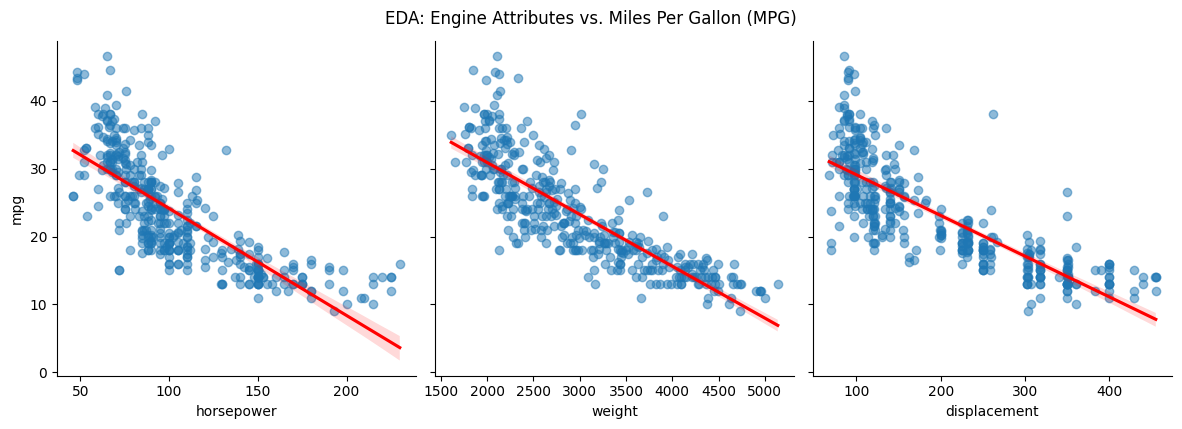


--- CORRELATION WITH TARGET (MPG) ---
weight         -0.832244
displacement   -0.805127
horsepower     -0.778427
mpg             1.000000
Name: mpg, dtype: float64


In [4]:

# ==========================================
# 3. Exploratory Data Analysis (EDA)
# ==========================================
# Visualizing the relationships between real physical attributes and MPG
sns.pairplot(df, x_vars=features, y_vars=[target], height=4, aspect=1, kind='reg', 
             plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.5}})
plt.suptitle("EDA: Engine Attributes vs. Miles Per Gallon (MPG)", y=1.05)
plt.show()

print("\n--- CORRELATION WITH TARGET (MPG) ---")
print(df[features + [target]].corr()[target].sort_values())


In [5]:

# ==========================================
# 4. Data Splitting & Feature Scaling
# ==========================================
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CRITICAL SVR REQUIREMENT: Scaling
# Look at the raw data: 'weight' is in the thousands (e.g., 3500 lbs), 
# while 'horsepower' is in the hundreds (e.g., 130 hp).
# Without scaling, SVR's distance calculations will heavily bias toward weight and ignore horsepower.
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Optional but recommended for SVR: Scale the target variable as well
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

In [6]:
# ==========================================
# 5. Train SVR Model
# ==========================================
# Using RBF kernel because the EDA pairplot shows a curve (non-linear relationship) 
# between horsepower/displacement and MPG, rather than a perfectly straight line.
svr_model = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1)
svr_model.fit(X_train_scaled, y_train_scaled)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [11]:
from sklearn.metrics import  accuracy_score


# ==========================================
# 6. Evaluation on Real Test Data
# ==========================================
# Predict and inverse-transform to get predictions back into actual MPG scale
y_pred_scaled = svr_model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

print("\n--- MODEL EVALUATION ON UNSEEN TEST DATA ---")
print(f"R² Score: {r2_score(y_test, y_pred):.4f} (Explains ~{r2_score(y_test, y_pred)*100:.1f}% of the variance)")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.2f} MPG (Average prediction error)")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} MPG")



--- MODEL EVALUATION ON UNSEEN TEST DATA ---
R² Score: 0.7234 (Explains ~72.3% of the variance)
MAE:      2.81 MPG (Average prediction error)
RMSE:     3.76 MPG


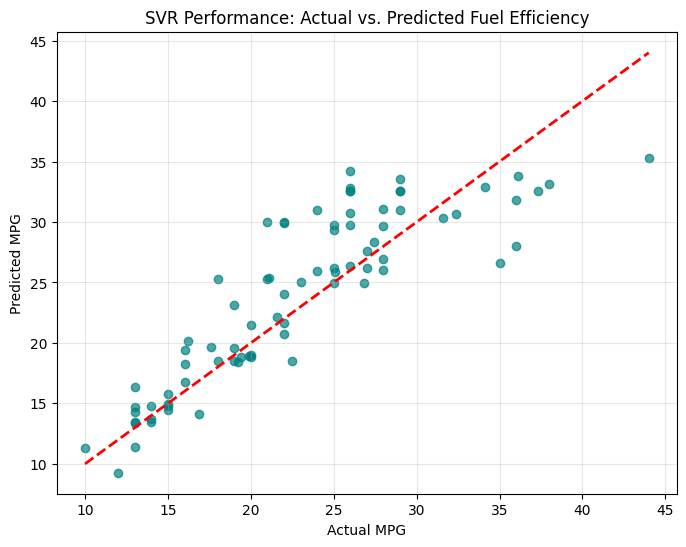

In [8]:



# ==========================================
# 7. Visualize Actual vs Predicted Real Values
# ==========================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("SVR Performance: Actual vs. Predicted Fuel Efficiency")
plt.grid(True, alpha=0.3)
plt.show()